In [1]:
# Loading Datas 

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot  as plt

df = pd.read_csv("adult.csv", header=0)


# 📊 Bivariate Analysis: Exploring Relationships Between Variables :

So far, we've focused on univariate analysis, which examines each variable independently. However, in reality, variables often influence or correlate with one 
another. That’s where bivariate analysis comes in—it investigates the relationship between two variables to uncover patterns, trends, or associations.

🔍 Why Bivariate Analysis Matters:

-	Helps identify correlations (positive, negative, or none)
- 	Reveals cause-effect relationships (though not always causation)
- 	Supports predictive modeling and decision-making
- 	Enhances understanding of data structure and behaviorlone variables but in rality variables are related to others. Bivariation analisis studies the relation between multiple variables.

# 📊  Contingency table

A contingency table displays the frequency (or count) of observations that fall into each combination of categories for two variables.
One variable is typically shown in the rows, and the other in the columns.

In [2]:
contingency_Table = pd.crosstab(df["sex"], df["education"], margins=True)

contingency_Table

education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college,All
sex,,,,,,,,,,,,,,,,,
Female,295,432,144,46,84,160,144,421,500,1619,86,3390,536,16,92,2806,10771
Male,638,743,289,122,249,486,370,646,882,3736,327,7111,1187,35,484,4485,21790
All,933,1175,433,168,333,646,514,1067,1382,5355,413,10501,1723,51,576,7291,32561


## 📊 Covariance with Two Variables

**Covariance** measures how two variables change together:

- **Positive covariance** → when one variable increases, the other tends to increase.
- **Negative covariance** → when one variable increases, the other tends to decrease.
- **Near zero** → little or no linear relationship.

### 🧮 Covariance Matrix for Two Variables

When using `np.cov(x, y)` , the output is a **2×2 matrix**:
- **Diagonal elements** → variance of each variable (how much each varies on its own).
- **Off-diagonal elements** → covariance between X and Y (same value in both positions).



In [3]:
age_hours_df = df[["age", "hours-per-week"]]

covariation = np.cov(age_hours_df["age"], age_hours_df["hours-per-week"], ddof =0)
print("Covariation :\n", covariation)


Covariation :
 [[186.05568601  11.57977407]
 [ 11.57977407 152.45431279]]


## 📈 Pearson Correlation Coefficient(r)

The **Pearson correlation coefficient** measures the **strength and direction** of the **linear relationship** between two variables.  
It is a **standardized** measure, meaning its value is always between **-1 and 1**, regardless of the scale of the variables.


### 📊 Interpretation of (r):
| Value of ( r ) | Interpretation |
|------------------|----------------|
| **+1**           | Perfect positive linear relationship |
| **0.7 to 0.9**   | Strong positive relationship |
| **0.3 to 0.7**   | Moderate positive relationship |
| **0 to 0.3**     | Weak positive relationship |
| **0**            | No linear relationship |
| **-0.3 to 0**    | Weak negative relationship |
| **-0.7 to -0.3** | Moderate negative relationship |
| **-0.9 to -0.7** | Strong negative relationship |
| **-1**           | Perfect negative linear relationship |

note : diagonal values are perfectly correlated between each other so the diagonal's values will be always one


In [4]:
r = age_hours_df.corr()
print("Correlation of perarnson :\n", r)

Correlation of perarnson :
                      age  hours-per-week
age             1.000000        0.068756
hours-per-week  0.068756        1.000000


## ⚫ Scatter Plot Graph :

### 📌 What is a Scatter Plot?
A scatter plot is a basic yet powerful visualization that shows the relationship between two numerical variables.  
Each point represents an observation, with:
- The x-axis showing one variable
- The y-axis showing another

Scatter plots are ideal for spotting:
- Trends (linear, nonlinear)
- Correlations
- Clusters
- Outliers

### 🧠 How to Interpret a Scatter Plot

1. Direction of the Pattern
   - Upward slope → positive relationship (as X increases, Y increases)
   - Downward slope → negative relationship (as X increases, Y decreases)
   - No clear slope → weak or no relationship

2. Spread of Points
   - Tightly clustered → stronger relationship
   - Widely scattered → weaker relationship

3. Outliers
   - Points far from the general pattern may indicate anomalies or special cases

4. Grouping (Optional)
   - You can use color or marker style to represent categories or groups

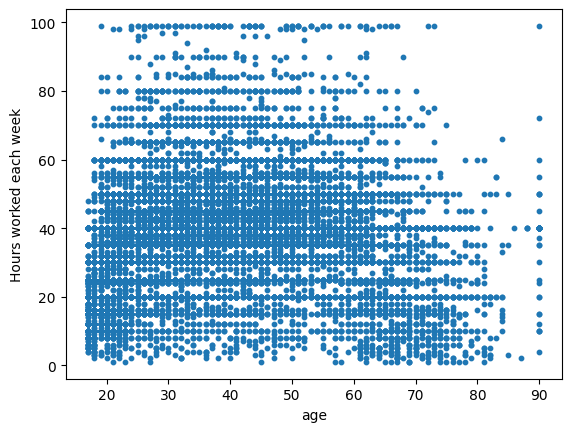

In [5]:
plt.scatter(age_hours_df["age"], age_hours_df["hours-per-week"], s = 10)
plt.xlabel("age")
plt.ylabel("Hours worked each week")
plt.show()

## 🔥 Heatmap Graph

### 📌 What is a Heatmap?
A heatmap is a graphical representation of data where individual values are shown as colors.  
In data analysis, heatmaps are often used to visualize:
- Correlation matrices (relationships between variables)
- Frequency tables (counts of category combinations)
- Any 2D data where color intensity can represent magnitude

In Seaborn, sns.heatmap() is commonly used to quickly turn a numeric matrix into a color-coded visualization.

### 🧠 How to Interpret a Heatmap
1. Color Scale  
   - The color bar (legend) shows how colors map to numeric values.  
   - Darker/brighter colors usually represent higher values, lighter colors lower values (depending on the chosen palette).

2. Cell Values  
   - Each cell’s position corresponds to a pair of variables (row vs. column).
   - The color intensity tells you the magnitude of the value.
   - If annot=True is set in Seaborn, the exact numeric value is displayed inside each cell.

3. Symmetry in Correlation Heatmaps  
   - For correlation matrices, the heatmap is symmetric along the diagonal.
   - The diagonal always shows 1.0 (a variable’s correlation with itself).

4. Interpreting Correlation Heatmaps  
   - Values close to +1 → strong positive linear relationship.
   - Values close to -1 → strong negative linear relationship.
   - Values near 0 → little or no linear relationship.
   - Look for clusters of high correlation to identify related variables.

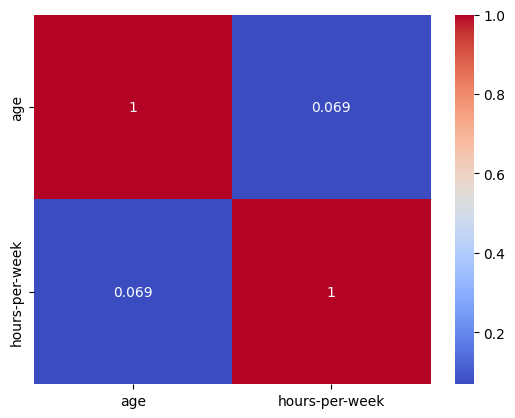

In [6]:
sns.heatmap(r, annot=True, cmap= "coolwarm")
plt.show()

## 🔗 Pairplot graph

### 📌 What is a Pairplot?
A pairplot is a powerful visualization tool that shows pairwise relationships between multiple variables in a dataset.  
It creates a grid of plots:
- Scatter plots for every pair of numerical variables
- Histograms or density plots on the diagonal to show individual distributions

This makes it easy to spot:
- Correlations
- Clusters
- Outliers
- Patterns across categories (if hue is used)

### 🧠 How to Interpret a Pairplot

1. Diagonal Plots  
   - Show the distribution of each variable (usually as histograms or KDE curves).
   - Help you understand the spread, skewness, and modality of each variable.

2. Off-Diagonal Scatter Plots  
   - Each cell shows how two variables relate to each other.
   - Look for:
     - Linear trends → possible correlation
     - Clusters → potential groupings or categories
     - Outliers → points far from the general pattern

3. Hue Parameter (Optional)  
   - Use hue='category' to color points by a categorical variable.
   - Helps compare how different groups behave across variable pairs.

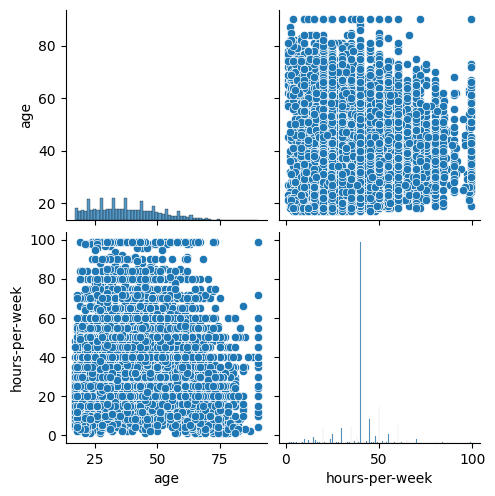

In [7]:
sns.pairplot(age_hours_df)
plt.show() # from this graph we can see that no correlation exists between age and hours worked